# Week 4: In-Class Exercises
Due: 3:00 PM Friday Sept. 25th on HuskyCT  
Submit with filename: `w4_[LASTNAME].ipynb`

```{exercise} Numerical Integrators
:label: icc_4-1
:number: 1

Let's write our own numerical integration methods for data on a discrete set of points. 

1. Set up functions to calculate the numerical integral of a set of values $f$ defined on a regularly spaced grid $x$ using:
+  Trapezoid rule `I_trapezoid()`
+  Simpson's rule `I_simpson()` * think about the indexing on this one!

2. Calculate the value of the integral $$x^4 - 2x + 1$ from $x=0$ to $x=2$ using $N = 10, 100, 1000$ cells. 

3. Compare both methods to the analytic value (Calculate the errors.)

```

In [182]:
import numpy as np
def f(x):
    return x**4 - 2*x + 1

def F(x):
    return 0.2*x**5 - x**2 + x

def I_trapezoid(f_i, x_i):
    """ Calculate the integral on a grid x_i given the values f_i using the trapezoid method"""
    I = 0
    ##
    return I

def I_simpson(f_i,x_i):
    """ Calculate the integral on a grid x_i given the values f_i using Simpsons method"""
    I = 0
    ##
    return I

a = 0
b = 2

I_a = F(b) - F(a)

print("Analytic I:", I_a)

for N in [10,100,1000]:
    x_i = np.linspace(a,b,N+1)
    f_i = f(x_i)
    I_t = I_trapezoid(f_i,x_i)
    I_s = I_simpson(f_i,x_i)
    print("N={}, Trapezoid: {}, Simpson's:{}".format(N,I_t,I_s))
    print("N={}, Trap error: {}, Simpson's error:{}".format(N,I_t-I_a,I_s-I_a))


Analytic I: 4.4
N=10, Trapezoid: 0, Simpson's:0
N=10, Trap error: -4.4, Simpson's error:-4.4
N=100, Trapezoid: 0, Simpson's:0
N=100, Trap error: -4.4, Simpson's error:-4.4
N=1000, Trapezoid: 0, Simpson's:0
N=1000, Trap error: -4.4, Simpson's error:-4.4


```{exercise} Numerical Error
:label: icc_4-2
:number: 2

Let's compare how we can quantify numerical error: the difference between the exact and numerical solution.

1. Calculate the Euler-Maclaurin Error for Trapezoidal integration.

2. Use the trapezoidal integral for $N = 10, 20, 40, 80, 160, 320$ to calculate the error for the function in the previous exercise relative to the value of the analytic integral.

3. Use the previous step of the trapezoidal integral to calculate the error using the difference of the two steps. 

4. Compare all three methods of error estimation

```

In [183]:
a = 0
b = 2

def fprime(x):
    return 4*x**3 - 2 

def EulerMaclaurin(h,a,b,fp):
    """calculate the EM estimate for Trapezoidal method"""
    return np.abs(h**2 * (fp(a) - fp(b))/12.)

I_t0 = 0
##for N in [10,20,40,80,160,320]:
    ##
    #print('N= {}, EM error:{}, estimate: {}, actual error: {}'.format(N, EulerMaclaurin(h,a,b,fprime), epsilon, I_t1 - I_a))


```{exercise} Adaptive Error Steps
:label: icc_4-3
:number: 3

Based on the code from the previous exercise, write a new program to:

1. Perform a Richardson Extrapolation to correct for the error in the numerical integral. 
2. Record the old error and the new error.
3. Make a plot to show that the new error is $\mathcal{O}(h^4)$

```

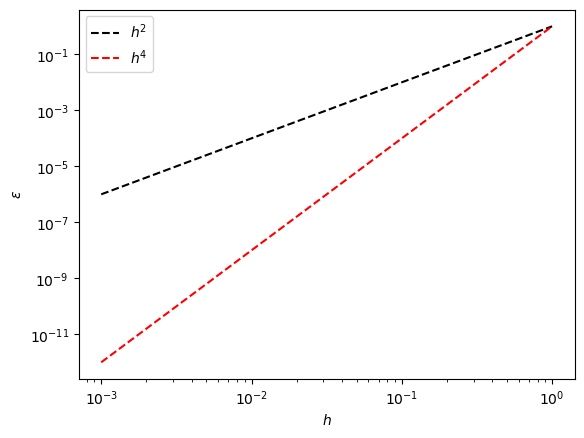

In [184]:
from matplotlib import pyplot as plt

a = 0
b = 2

I_t0 = 0

###

fig,ax=plt.subplots(1)
###

ax.set_xlabel(r'$h$')
ax.set_ylabel(r'$\epsilon$')

# list comprehension for quick plotting
ax.loglog(*zip(*[[x,x**2] for x in np.logspace(-3,0,100)]),color='black',label="$h^2$",ls='dashed')
ax.loglog(*zip(*[[x,x**4] for x in np.logspace(-3,0,100)]),color='red',label = "$h^4$",ls='dashed')
ax.legend()

```{exercise} Gaussian Quadrature
:label: icc_4-4
:number: 4

Gaussian Quadrature did a fairly good job of integrating our polynomial by approximating it with a set of polynomials... Go figure. 

Play around with the code and come up with a function for which Gaussian Quadrature produces a higher error at the same $N=4$.   
What kind of functions break this method and why?

Make sure you have downloaded [gaussxw.py](./gaussxw.py). 


```

N = 4 --> integral = 0.946061363026411 error = 0.8868695692077502


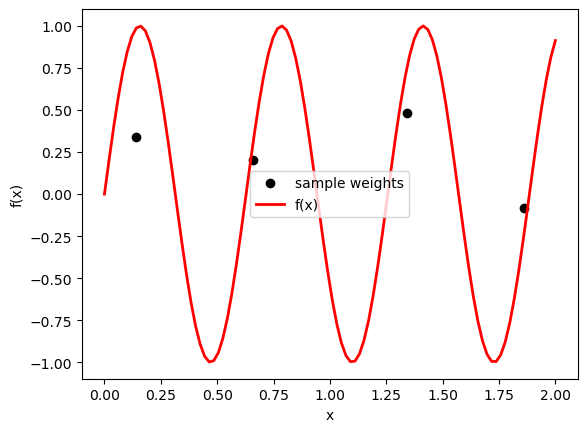

In [181]:
from gaussxw import gaussxw
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 2*x + 1

def F(x):
    return 0.2*x**5 - x**2 + x

N = 4
a = 0.0
b = 2.0
I_a = F(b) - F(a)
# calculate the sample points and weights
x, w = gaussxw(N)

# map the sample points and weights to the required domain
xp = 0.5*(b-a)*x + 0.5*(b+a)
wp = 0.5*(b-a)*w


# perform the integral
I = 0.0
for k in range(N):
    I += wp[k] * f(xp[k])

print('N =',N, '--> integral =',I, 'error =', abs(I-I_a))

fig,ax = plt.subplots()
ax.plot(xp,wp*f(xp),'ko',label='sample weights')
ax.plot(*zip(*[[x,f(x)] for x in np.linspace(a,b,100)]),color='red',lw=2,label='f(x)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()


```{exercise} Taking Sides
:label: icc_4-5
:number: 5

[Last week's exercises](./3a_exercises.ipynb) had you take a forward-difference for $f(x) = \sin(x)$. 
1. Based on the code for exercise 3 from last week, add functions to compute the numerical derivative using a backward difference and a central difference scheme. 
2. Make a plot of all three methods and the analytic value. Plot the numerical derivatives as points and the analytic expression as a line. 
3. Include a panel with the residual of all three schemes. 


```

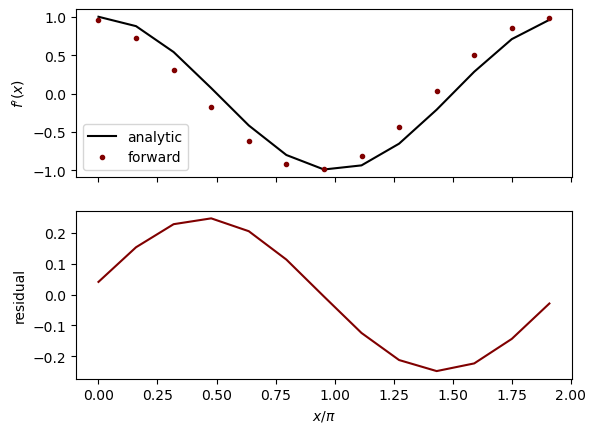

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

def f(x):
    """our function to numerically differentiate"""
    return np.sin(x)

def fprime(x):
    """the analytic derivative of f"""
    return np.cos(x)

def Dh_f(x, h):
    """a discrete approximation to the derivative at x using forward difference"""
    return (f(x+h) - f(x))/h

def Dh_b(x, h):
    """a discrete approximation to the derivative at x using backward difference"""
    return 0

def Dh_c(x, h):
    """a discrete approximation to the derivative at x using central difference"""
    return 0


h = 0.5
x = np.arange(0,2*pi,h)
cf,cb,cc = 'maroon','navy','teal'
fig,ax = plt.subplots(2,sharex=True)

ax[0].plot(x/pi,fprime(x),label='analytic',color='black')
ax[0].plot(x/pi,Dh_f(x,h=h), label='forward',lw=0,color=cf,marker='.')
#ax[0].plot(x/pi,Dh_b(x,h=h), label='backward',lw=0,color=cb,marker='.')
#ax[0].plot(x/pi,Dh_c(x,h=h), label='central',lw=0,color=cc,marker='.')
ax[0].set_ylabel(r'$f^\prime(x)$')

ax[1].plot(x/pi,fprime(x)-Dh_f(x,h),color=cf)
#ax[1].plot(x/pi,fprime(x)-Dh_b(x,h),color=cb)
#ax[1].plot(x/pi,fprime(x)-Dh_c(x,h),color=cc)
ax[1].set_ylabel('residual')
ax[1].set_xlabel(r'$x/\pi$')
ax[0].legend()

## Synthesis Question
*Discuss the following prompt in a new markdown cell below*

> Q: By looking at the residuals in the above plot, you will notice that forward and backward differencing display different behaviors in the error in specific regimes of the plot. Describe this behavior and how it relates to the function and it's derivative.